Dataset:
       Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0    Sunny    Warm   Normal  Strong  Warm     Same        Yes
1    Sunny    Warm     High  Strong  Warm     Same        Yes
2    Rainy    Cold     High  Strong  Warm   Change         No
3    Sunny    Warm     High  Strong  Cool   Change        Yes
4   Cloudy    Warm   Normal    Weak  Warm     Same        Yes
5    Sunny    Cold   Normal    Weak  Warm     Same         No
6    Rainy    Cold     High  Strong  Cool   Change         No
7    Sunny    Warm     High    Weak  Warm     Same        Yes
8   Cloudy    Cold   Normal  Strong  Cool   Change         No
9    Sunny    Warm     High  Strong  Warm     Same        Yes
10   Rainy    Warm   Normal    Weak  Warm   Change         No
11   Sunny    Cold     High  Strong  Cool     Same        Yes
12  Cloudy    Warm     High    Weak  Warm   Change         No
13   Sunny    Warm   Normal  Strong  Cool     Same        Yes
14   Rainy    Cold     High    Weak  Warm   Change         No

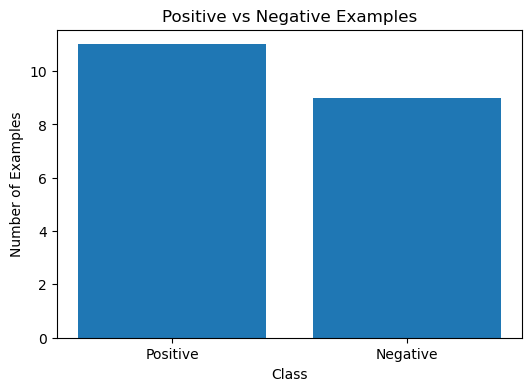

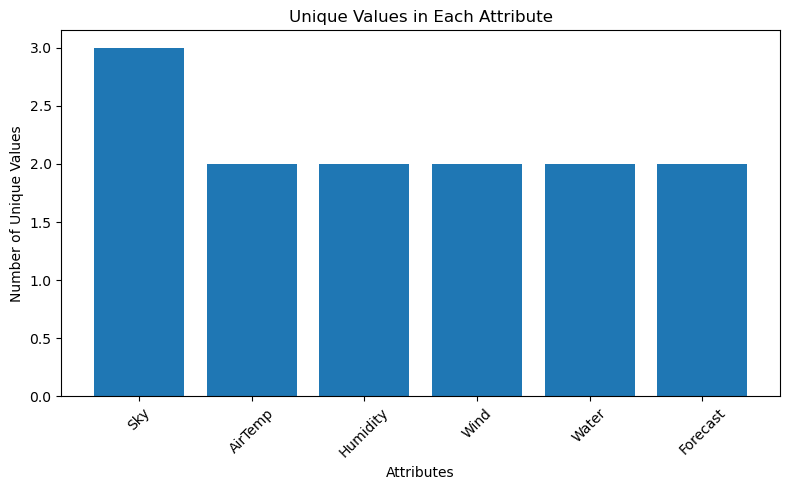

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("find_s_dataset.csv")

print("Dataset:")
print(data)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

attributes = X.columns.tolist()

# Initialize S and G
S = ['0'] * len(attributes)
G = [['?'] * len(attributes)]


# ---------- CANDIDATE ELIMINATION ----------

for i in range(len(data)):

    example = X.iloc[i].tolist()
    target = str(y.iloc[i]).lower()

    if target == "yes":

        # Update Specific Hypothesis S
        for j in range(len(attributes)):

            if S[j] == '0':
                S[j] = example[j]

            elif S[j] != example[j]:
                S[j] = '?'

        # Remove G hypotheses that don't cover positive example
        new_G = []

        for g in G:

            valid = True

            for j in range(len(attributes)):

                if g[j] != '?' and g[j] != example[j]:
                    valid = False
                    break

            if valid:
                new_G.append(g)

        G = new_G


    elif target == "no":

        # Specialize G using negative example
        new_G = []

        for g in G:

            for j in range(len(attributes)):

                if g[j] == '?':

                    for value in X.iloc[:, j].unique():

                        if value != example[j]:

                            new_g = g.copy()
                            new_g[j] = value

                            # Check consistency with S
                            valid = True

                            for k in range(len(attributes)):

                                if S[k] != '0' and S[k] != '?':

                                    if new_g[k] != '?' and new_g[k] != S[k]:
                                        valid = False
                                        break

                            if valid:
                                new_G.append(new_g)

        G = new_G


# ---------- FINAL OUTPUT ----------

print("\n--------------------------------")
print("Candidate Elimination Result")
print("--------------------------------")

print("\nSpecific Hypothesis (S):")
print(S)

print("\nGeneral Hypotheses (G):")

if len(G) == 0:
    print("G is empty")

else:
    for i, g in enumerate(G, 1):
        print("G", i, ":", g)


# ---------- GRAPH 1 ----------

positive = sum(y.astype(str).str.lower() == "yes")
negative = sum(y.astype(str).str.lower() == "no")

plt.figure(figsize=(6, 4))

plt.bar(
    ["Positive", "Negative"],
    [positive, negative]
)

plt.title("Positive vs Negative Examples")
plt.xlabel("Class")
plt.ylabel("Number of Examples")

plt.show()


# ---------- GRAPH 2 ----------

unique_values = X.nunique()

plt.figure(figsize=(8, 5))

plt.bar(
    unique_values.index,
    unique_values.values
)

plt.title("Unique Values in Each Attribute")
plt.xlabel("Attributes")
plt.ylabel("Number of Unique Values")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()